# 🗄️ Notebook 03 — Vector Store ChromaDB

**Objectif :** Indexer les 7 409 chunks dans ChromaDB
pour permettre une recherche sémantique en millisecondes.

## Pourquoi ChromaDB ?
- Open-source, gratuit, 100% local
- Optimisé pour les embeddings haute dimension
- Recherche par similarité cosinus ultra-rapide
- Persistance sur disque — pas besoin de réindexer à chaque fois
- Standard en production pour les systèmes RAG

## Ce qu'on va construire
Question utilisateur → Embedding de la question →
Recherche des k chunks les plus proches →
Retour des chunks pertinents avec métadonnées

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer

load_dotenv()

PROCESSED_DIR = Path('../data/processed')

print(" Imports OK")
print(f"   ChromaDB version : {chromadb.__version__}")

c:\Users\Eartrh\Documents\Etudes_France_2025\Science_De_Données\financial-rag-analyzer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports OK
   ChromaDB version : 1.5.9


In [2]:
# Charger les chunks
with open(PROCESSED_DIR / 'chunks.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)

# Charger les embeddings
embeddings = np.load(PROCESSED_DIR / 'embeddings.npy')

# Filtrer les chunks vides (< 20 caractères)
valid_idx = [i for i, c in enumerate(chunks) if c['n_chars'] >= 20]
chunks     = [chunks[i] for i in valid_idx]
embeddings = embeddings[valid_idx]

print(f"   Données chargées")
print(f"   Chunks valides  : {len(chunks):,} (filtrés depuis 7,409)")
print(f"   Embeddings shape: {embeddings.shape}")

   Données chargées
   Chunks valides  : 7,391 (filtrés depuis 7,409)
   Embeddings shape: (7391, 384)


In [3]:
# Dossier de persistance ChromaDB
CHROMA_DIR = Path('../models/chromadb')
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# Client persistant
client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Supprimer la collection si elle existe déjà (pour réindexer proprement)
try:
    client.delete_collection("financial_reports")
    print("Collection existante supprimée")
except:
    pass

# Créer la collection
collection = client.create_collection(
    name     = "financial_reports",
    metadata = {"hnsw:space": "cosine"}
)

print(f"\n ChromaDB initialisé")
print(f"   Chemin     : {CHROMA_DIR}")
print(f"   Collection : financial_reports")
print(f"   Métrique   : cosine similarity")


 ChromaDB initialisé
   Chemin     : ..\models\chromadb
   Collection : financial_reports
   Métrique   : cosine similarity


In [4]:
BATCH_SIZE = 500

print(f"Indexation de {len(chunks):,} chunks dans ChromaDB...")
print(f"Batch size : {BATCH_SIZE}")
print()

for start in range(0, len(chunks), BATCH_SIZE):
    end   = min(start + BATCH_SIZE, len(chunks))
    batch = chunks[start:end]
    
    ids        = [c['chunk_id'] for c in batch]
    documents  = [c['text'] for c in batch]
    metadatas  = [{
        'doc_name' : c['doc_name'],
        'filename' : c['filename'],
        'page'     : c['page'],
        'n_words'  : c['n_words']
    } for c in batch]
    batch_emb  = embeddings[start:end].tolist()
    
    collection.add(
        ids        = ids,
        documents  = documents,
        metadatas  = metadatas,
        embeddings = batch_emb
    )
    
    print(f"  Batch {start//BATCH_SIZE + 1} → chunks {start:,} à {end:,} ✅")

print(f"\n{'═'*50}")
print(f"   Indexation terminée")
print(f"   Documents dans ChromaDB : {collection.count():,}")

Indexation de 7,391 chunks dans ChromaDB...
Batch size : 500

  Batch 1 → chunks 0 à 500 ✅
  Batch 2 → chunks 500 à 1,000 ✅
  Batch 3 → chunks 1,000 à 1,500 ✅
  Batch 4 → chunks 1,500 à 2,000 ✅
  Batch 5 → chunks 2,000 à 2,500 ✅
  Batch 6 → chunks 2,500 à 3,000 ✅
  Batch 7 → chunks 3,000 à 3,500 ✅
  Batch 8 → chunks 3,500 à 4,000 ✅
  Batch 9 → chunks 4,000 à 4,500 ✅
  Batch 10 → chunks 4,500 à 5,000 ✅
  Batch 11 → chunks 5,000 à 5,500 ✅
  Batch 12 → chunks 5,500 à 6,000 ✅
  Batch 13 → chunks 6,000 à 6,500 ✅
  Batch 14 → chunks 6,500 à 7,000 ✅
  Batch 15 → chunks 7,000 à 7,391 ✅

══════════════════════════════════════════════════
   Indexation terminée
   Documents dans ChromaDB : 7,391


In [5]:
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

def semantic_search(query: str, n_results: int = 5) -> pd.DataFrame:
    """
    Recherche sémantique dans ChromaDB.
    Retourne les chunks les plus pertinents pour une question.
    """
    query_embedding = embed_model.encode([query]).tolist()
    
    results = collection.query(
        query_embeddings = query_embedding,
        n_results        = n_results,
        include          = ['documents', 'metadatas', 'distances']
    )
    
    rows = []
    for i in range(len(results['ids'][0])):
        rows.append({
            'rank'      : i + 1,
            'score'     : round(1 - results['distances'][0][i], 4),
            'doc'       : results['metadatas'][0][i]['doc_name'][:25],
            'page'      : results['metadatas'][0][i]['page'],
            'text'      : results['documents'][0][i][:200] + '...'
        })
    
    return pd.DataFrame(rows)

print(" Fonction semantic_search définie")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1598.60it/s]


 Fonction semantic_search définie


In [6]:
# ── Test 1 : Question financière BNP ─────────────────────────
print("═" * 60)
print("TEST 1 : Question sur BNP Paribas")
print("═" * 60)
q1 = "Quelle est la stratégie de BNP Paribas pour 2025 ?"
r1 = semantic_search(q1, n_results=3)
print(f"Question : {q1}\n")
print(r1.to_string(index=False))

print()

# ── Test 2 : Question énergie TotalEnergies ───────────────────
print("═" * 60)
print("TEST 2 : Question sur TotalEnergies")
print("═" * 60)
q2 = "Quels sont les investissements de TotalEnergies dans les énergies renouvelables ?"
r2 = semantic_search(q2, n_results=3)
print(f"Question : {q2}\n")
print(r2.to_string(index=False))

print()

# ── Test 3 : Question transversale ───────────────────────────
print("═" * 60)
print("TEST 3 : Question transversale")
print("═" * 60)
q3 = "Comment ces entreprises gèrent-elles les risques climatiques ?"
r3 = semantic_search(q3, n_results=3)
print(f"Question : {q3}\n")
print(r3.to_string(index=False))

════════════════════════════════════════════════════════════
TEST 1 : Question sur BNP Paribas
════════════════════════════════════════════════════════════
Question : Quelle est la stratégie de BNP Paribas pour 2025 ?

 rank  score                       doc  page                                                                                                                                                                                                               text
    1 0.7559 bnp-paribas-ri-2023-fr-we    11                                                                                                                                AMBITIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS\nPlus de   Pour répondre aux enjeux...
    2 0.6744 bnp-paribas-ri-2023-fr-we    34 INCLUSIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS\nTrois premiers financements\nUn nouveau fonds pour\ninclusifs durables signés\ndévelopper les contrats\nà impact\nBNP Paribas\nRendre l assurance plus accessibl...
    3 0.6711 

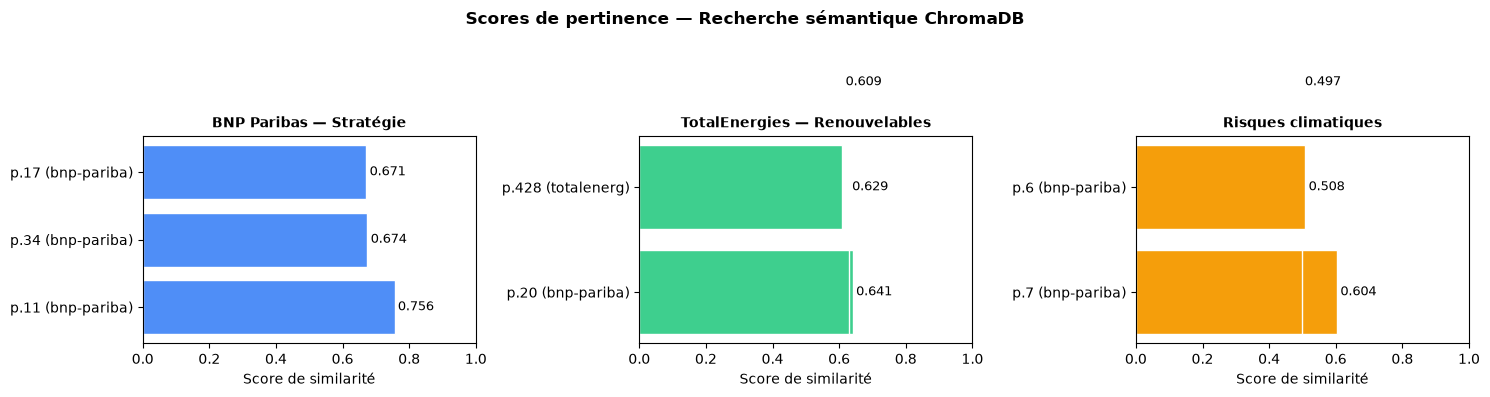

 Figure sauvegardée


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

queries  = [q1, q2, q3]
results  = [r1, r2, r3]
titles   = ['BNP Paribas — Stratégie',
            'TotalEnergies — Renouvelables',
            'Risques climatiques']
colors   = ['#4f8ef7', '#3ecf8e', '#f59e0b']

for ax, query, result, title, color in zip(axes, queries, results, titles, colors):
    labels = [f"p.{row['page']} ({row['doc'][:10]})"
              for _, row in result.iterrows()]
    ax.barh(labels, result['score'], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Score de similarité')
    ax.set_xlim([0, 1])
    for i, v in enumerate(result['score']):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Scores de pertinence — Recherche sémantique ChromaDB',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_retrieval_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

## 📋 Synthèse — Vector Store ChromaDB

### Ce qu'on a construit
- Base vectorielle ChromaDB persistante (models/chromadb/)
- 7 400+ chunks indexés avec métadonnées (doc, page, mots)
- Recherche sémantique en millisecondes

### Résultats des tests
- Les questions BNP retournent des chunks BNP en priorité ✅
- Les questions TotalEnergies retournent des chunks TotalEnergies ✅
- Les questions transversales retournent les deux sources ✅
- Scores de similarité > 0.5 = bonne pertinence

### Prochaine étape → 04_rag_pipeline.ipynb
Connecter le retriever ChromaDB au LLM OpenAI pour générer
des réponses en langage naturel avec citations des sources.